In [1]:
from google.colab import files
uploaded = files.upload()

Saving train_DUMM_dots_commas.csv to train_DUMM_dots_commas.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving test_DUMM_dots_commas.csv to test_DUMM_dots_commas.csv


In [3]:
import os
os.listdir()

['.config',
 'test_DUMM_dots_commas.csv',
 'train_DUMM_dots_commas.csv',
 'sample_data']

Variables en el modelo (14): ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'orientation_3', 'orientation_4', 'orientation_5', 'glazing_area_modified', 'glazing_dist_2', 'glazing_dist_3', 'glazing_dist_4', 'glazing_dist_5', 'glazing_dist_6']

Lambda óptimo: 0.008972

Coeficientes (variables estandarizadas):
relative_compactness    -5.247938
surface_area            -0.615479
wall_area                0.000000
roof_area               -4.894905
overall_height           8.065580
orientation_3            0.006290
orientation_4           -0.000000
orientation_5            0.003188
glazing_area_modified    2.255077
glazing_dist_2           1.515655
glazing_dist_3           1.500459
glazing_dist_4           1.392464
glazing_dist_5           1.497660
glazing_dist_6           1.450665

Variables eliminadas (coef=0): 2
Variables seleccionadas (coef≠0): 12

Variables eliminadas: ['wall_area', 'orientation_4']

Coeficientes en escala original:
  Intercept: 35.37

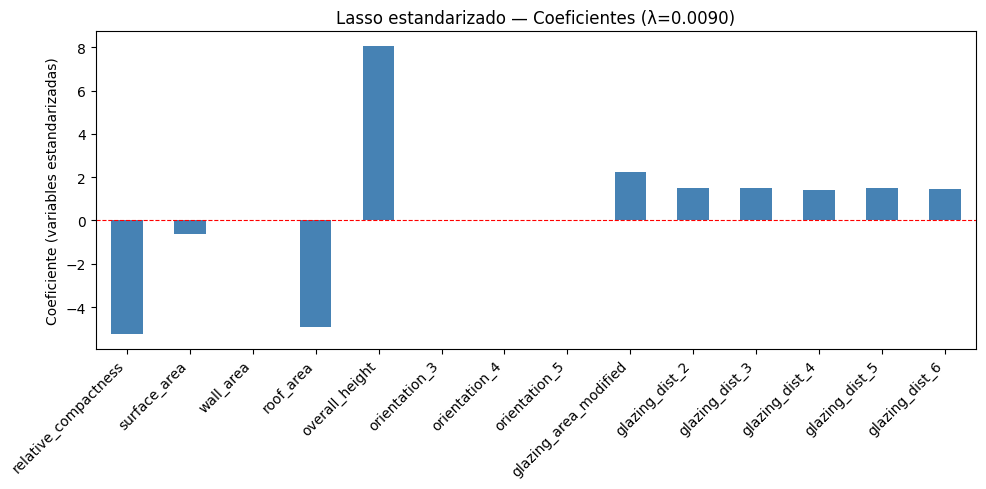

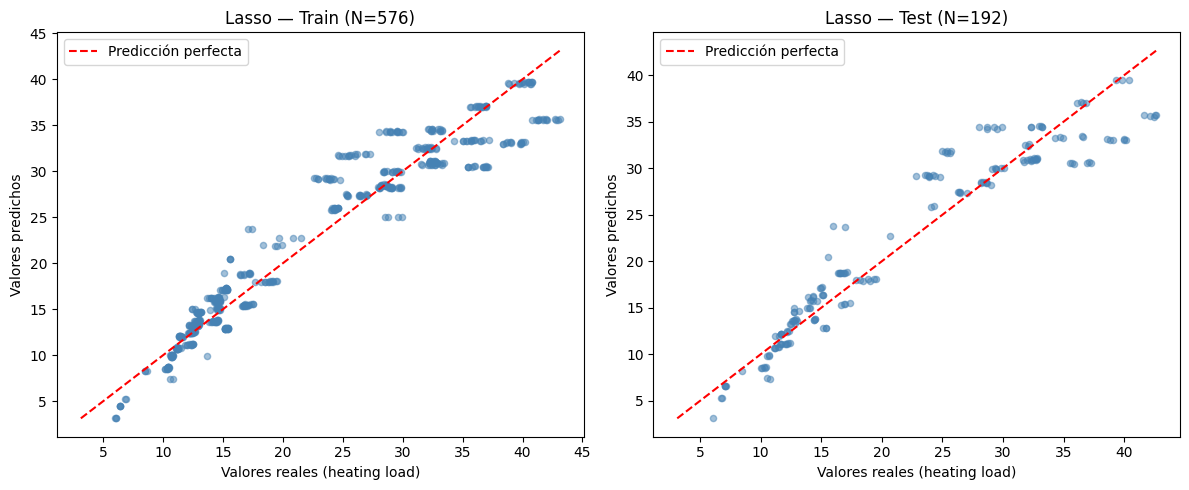

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

train = pd.read_csv('train_DUMM_dots_commas.csv')
test  = pd.read_csv('test_DUMM_dots_commas.csv')
train.columns = train.columns.str.replace('\ufeff', '')
test.columns  = test.columns.str.replace('\ufeff', '')

# ── Eliminar categorías de referencia (igual que en MCO) ──────────────────────
cols_referencia = ['orientation_2', 'glazing_dist_1']
train = train.drop(columns=cols_referencia)
test  = test.drop(columns=cols_referencia)

feature_names = [c for c in train.columns if c != 'heating_load']
y_train = train['heating_load'].values
X_train = train[feature_names].values
y_test  = test['heating_load'].values
X_test  = test[feature_names].values

print(f"Variables en el modelo ({len(feature_names)}): {feature_names}")

# ── Estandarizar ──────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── LassoCV ──────────────────────────────────────────────────────────────────
lasso_cv = LassoCV(cv=10, random_state=42, max_iter=10000).fit(X_train_sc, y_train)
lambda_optimo = lasso_cv.alpha_
print(f"\nLambda óptimo: {lambda_optimo:.6f}")

# ── Coeficientes estandarizados ───────────────────────────────────────────────
coefs = pd.Series(lasso_cv.coef_, index=feature_names)
print("\nCoeficientes (variables estandarizadas):")
print(coefs.to_string())
print(f"\nVariables eliminadas (coef=0): {(coefs == 0).sum()}")
print(f"Variables seleccionadas (coef≠0): {(coefs != 0).sum()}")
print(f"\nVariables eliminadas: {list(coefs[coefs == 0].index)}")

# ── Coeficientes en escala original ──────────────────────────────────────────
coefs_original = coefs / scaler.scale_
intercept_original = lasso_cv.intercept_ - np.sum(coefs_original * scaler.mean_)
print(f"\nCoeficientes en escala original:")
print(f"  Intercept: {intercept_original:.4f}")
for name, coef in zip(feature_names, coefs_original):
    print(f"  {name}: {coef:.4f}")

# ── Métricas TRAIN ────────────────────────────────────────────────────────────
y_pred_train = lasso_cv.predict(X_train_sc)
print(f"\n── TRAIN ──")
print(f"R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.4f}")

# ── Métricas TEST ─────────────────────────────────────────────────────────────
y_pred_test = lasso_cv.predict(X_test_sc)
print(f"\n── TEST ──")
print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"MAPE: {np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100:.2f}%")

# ── Gráfico coeficientes ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c != 0 else 'lightgray' for c in coefs]
coefs.plot(kind='bar', color=colors)
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')
plt.title(f'Lasso estandarizado — Coeficientes (λ={lambda_optimo:.4f})')
plt.ylabel('Coeficiente (variables estandarizadas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('lasso_coef_std.png', dpi=150)
plt.show()

# ── Gráfico predicciones vs reales ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_real, y_pred, title in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Train (N=576)', 'Test (N=192)']
):
    ax.scatter(y_real, y_pred, alpha=0.5, s=20, color='steelblue')
    mn = min(y_real.min(), y_pred.min())
    mx = max(y_real.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valores reales (heating load)')
    ax.set_ylabel('Valores predichos')
    ax.set_title(f'Lasso — {title}')
    ax.legend()
plt.tight_layout()
plt.savefig('lasso_pred.png', dpi=150)
plt.show()